# Phase 4 — Static SHAP (LightGBM)

Runs `src/explainability/static_shap.py`: refits LightGBM on the full `modeling_feature_set` (real data only) using the Phase 3 recipe (impute/encode on all data, SMOTE on the training data used to fit the model — no held-out split here since this is a deployed-artifact refit, not a new evaluation; Phase 3's k-fold already validated this recipe). Computes exact TreeExplainer SHAP values.

**Important subtlety**: SHAP explains the model's raw margin (log-odds) output, not the Phase 3 isotonic-calibrated probability — isotonic calibration is a single monotonic transform on the model's output as a whole, with no feature-by-feature decomposition, so Shapley attribution isn't defined "after" it. Additive consistency (`sum(shap_values) + base_value == raw model margin`) is asserted in the script and confirmed via `/leakage-check`. The Phase 3 calibrated probability is shown alongside the local explanation for context.

The local-explanation applicant is chosen using genuine out-of-fold calibrated PD (from `phase3_calibration_oof.csv`) closest to Phase 3's optimal threshold (0.220) — a real borderline approve/reject case — rather than from this refit's own in-sample predictions.

In [2]:
%run ../src/explainability/static_shap.py

Global SHAP: 5,000 sampled applicants, 54 features
Local explanation applicant: SK_ID_CURR=103191, OOF calibrated PD=0.2198 (Phase 3 optimal threshold=0.220), actual TARGET=0
Additive consistency check passed: base_value + sum(shap) = -1.2200 == raw model margin = -1.2200


## Global summary plot

Beeswarm summary over a random sample of 5,000 real applicants — feature impact (SHAP value, in log-odds) vs. feature value, ranked by mean |SHAP|.

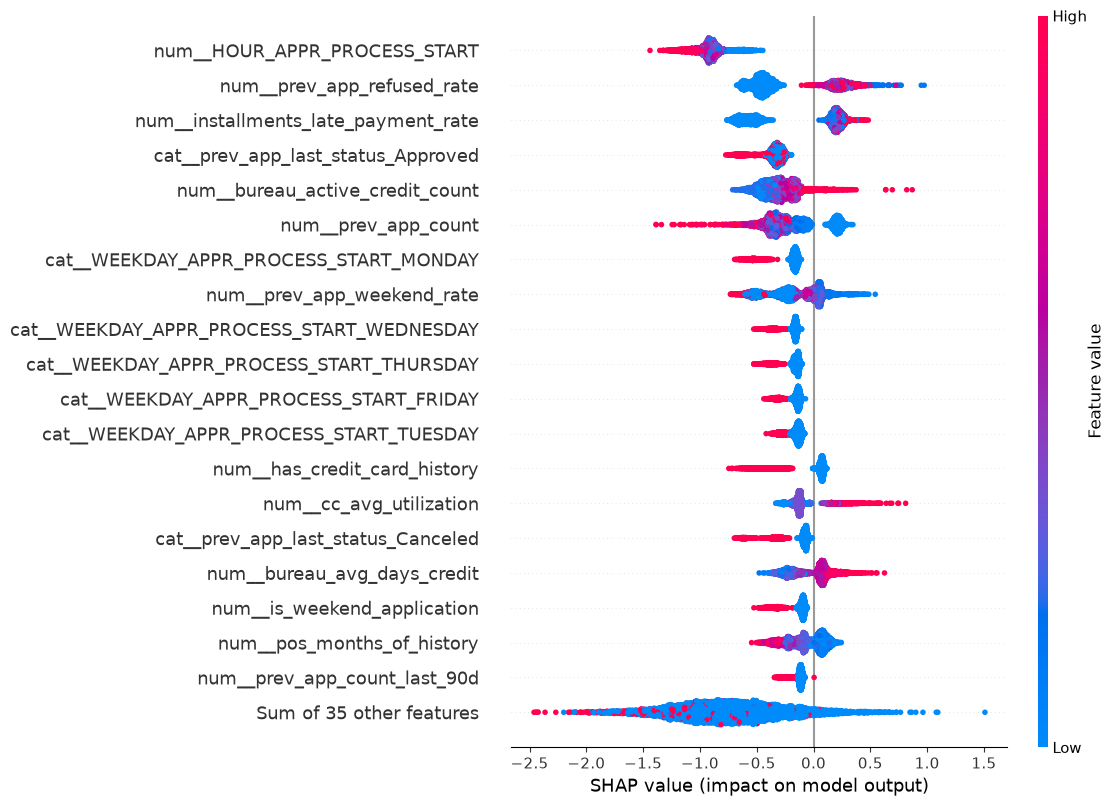

In [3]:
import shap

shap.plots.beeswarm(result["shap_values_sample"], max_display=20)

## Local explanation — one applicant near the decision threshold

This applicant's out-of-fold calibrated PD sits right at Phase 3's optimal threshold (0.220) — printed above by the script, along with their actual historical `TARGET`. The waterfall shows how each feature pushed this specific prediction away from the base rate, in log-odds space.

SK_ID_CURR=103191  OOF calibrated PD=0.2198  actual TARGET=0


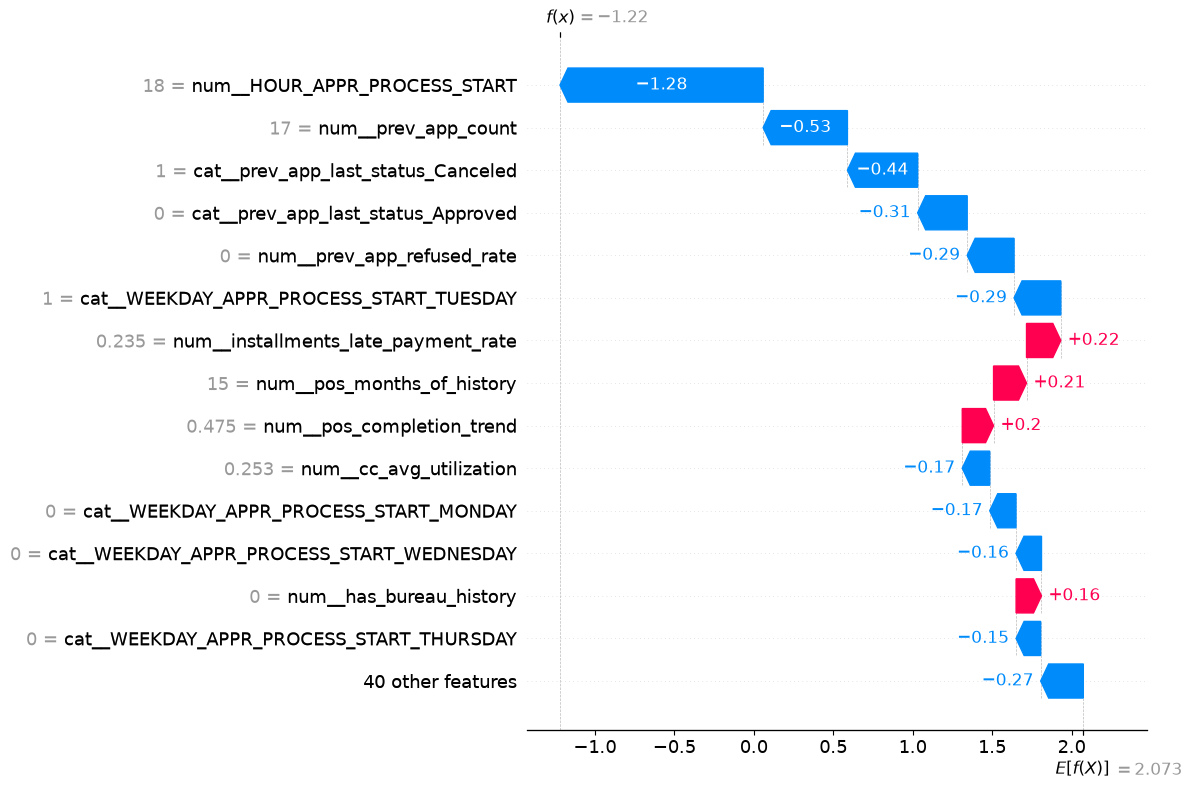

In [4]:
print(f"SK_ID_CURR={result['applicant_id']}  OOF calibrated PD={result['applicant_pd']:.4f}  actual TARGET={result['applicant_target']}")
shap.plots.waterfall(result["shap_values_applicant"][0], max_display=15)